[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ScriptsRemote/Transcend_SummerSchool/blob/main/Day2_Hydroeconomics_and_Water_Mapping/04_platforms_gee_colab_and_qgis.ipynb)

# Day 2 - Hydroeconomics & Water Mapping
## Session 4: Platforms - Google Earth Engine, Colab and QGIS

| | |
|---|---|
| **Fecha / Date** | 2026-10-13 (Tuesday / Martes) |
| **Horario / Time** | 15:40 - 17:10 |
| **Entidad / Entity** | SEI / IMDEA |
| **Instructores / Instructors** | Christhian, Sebastian |

### Contenido / Content

> Platforms, accounts and installation. GEE Community registration, cloud project, API authentication, first commands. Google Colab, QGIS 3.44 LTR and shared script repository

### Objetivos de aprendizaje / Learning objectives

- [ ] Describe what Earth Engine is, where the computation happens, and what the client library does
- [ ] Register an account, create a Cloud project and authenticate the Python API
- [ ] Load and inspect an `ee.Image` (NASADEM) and an `ee.ImageCollection` (Landsat 9)
- [ ] Define an area of interest in three ways - a point, a geometry drawn on the map, and a `FeatureCollection` asset - and visualise the result
- [ ] Export an image directly to the computer and to Google Drive with an export task

### Datos necesarios / Required data

An Earth Engine account with a Cloud project (section 4.2). All data is read from the
catalogue, except the vector asset used in section 4.7:
`projects/ee-christhianscunha/assets/transcend/TDP_map`.

---


## 4.1 - What Earth Engine is

Google Earth Engine is a cloud platform for planetary-scale geospatial analysis. It pairs a
multi-petabyte catalogue of satellite imagery and environmental data with the computing
power needed to analyse it, so that the work of storing, georeferencing and preprocessing
the archive is done once, centrally, instead of by every researcher who needs it. The
platform was described by its creators in
[Gorelick et al. (2017)](https://doi.org/10.1016/j.rse.2017.06.031), *Google Earth Engine:
Planetary-scale geospatial analysis for everyone*, Remote Sensing of Environment 202,
18-27 - still the standard reference to cite when you publish work made with it. The idea
in one line: bring the algorithm to the data, not the data to the algorithm.

<style>
img[alt="image-2.png"] { width: 600px; }
</style>
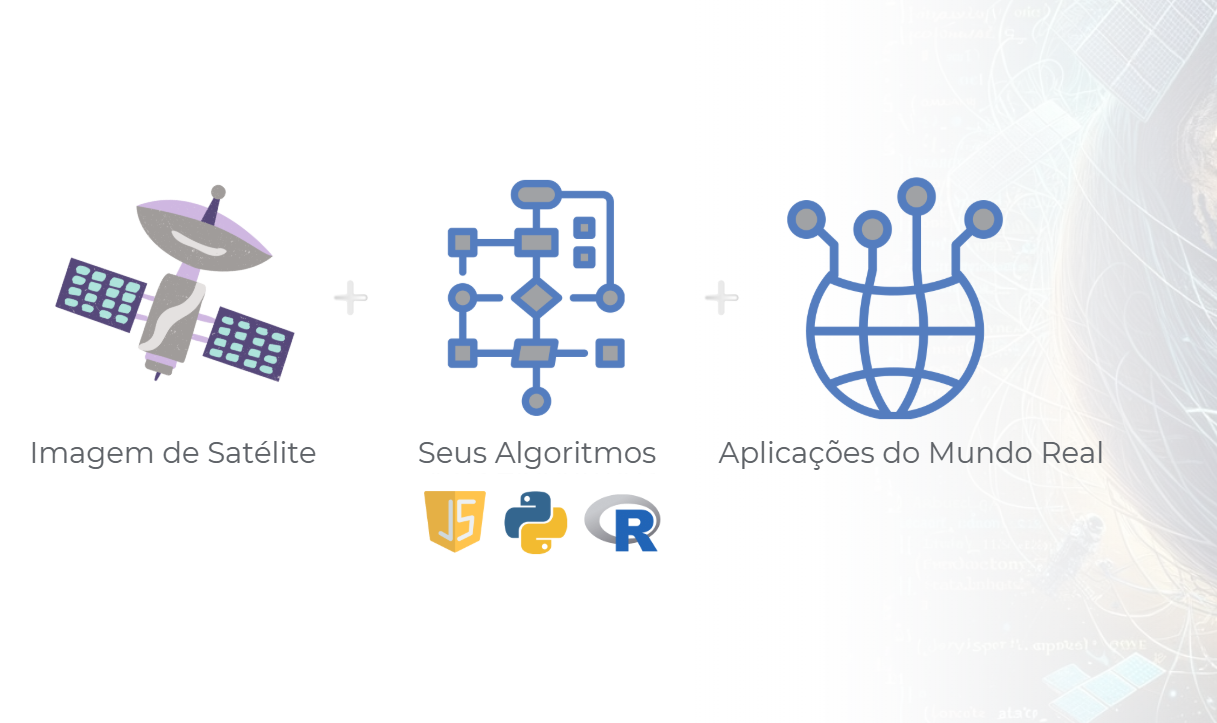

Google Earth Engine has two parts that are easy to confuse:

1. **A data catalogue.** Several petabytes of satellite imagery and geospatial products,
   already georeferenced, calibrated and kept up to date - the full Landsat archive since
   1972, Sentinel-1 and -2, MODIS, climate reanalyses, digital elevation models, land cover
   products. The data does not have to be downloaded or preprocessed.
2. **A processing service.** The computation runs on Google's infrastructure, close to the
   data, and is distributed across many machines.

3. **Not the same as Google Earth.** Despite the shared name, Earth Engine is not the
 globe you spin in Google Earth. Google Earth is a viewer: it renders a pre-made,
visually enhanced mosaic for you to look at. Earth Engine gives you the raw,
scientific-grade pixels - reflectance values, brightness temperatures, radar
backscatter - with their original bands, dates and metadata intact, and lets you
compute on them. In Google Earth you *look at* the Earth; in Earth Engine you *measure* it.

<style>
img[alt="image.png"] { width: 600px; }
</style>

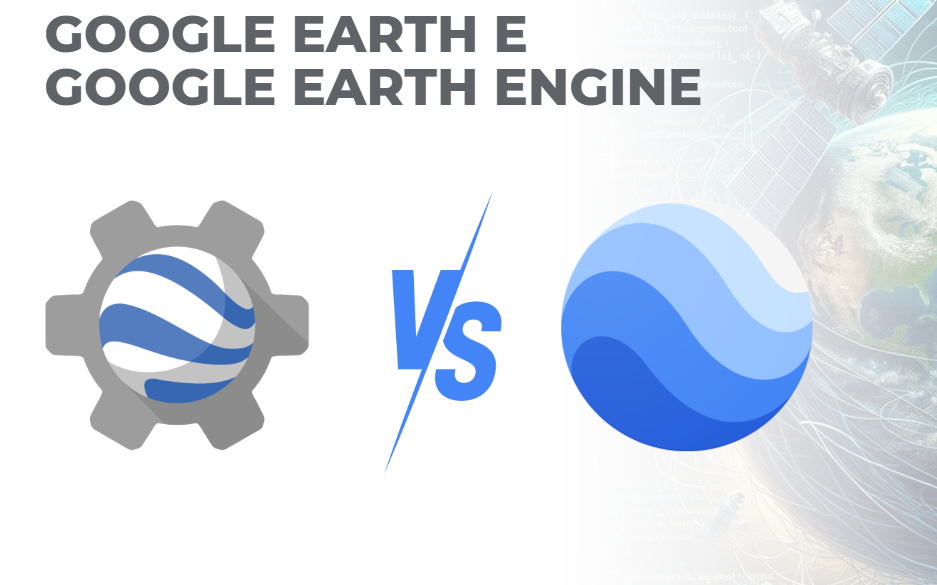

### The objects you will work with

Earth Engine exposes a small set of server-side types, and almost every script is a
combination of them. `Image` is the basic raster - a stack of named bands - and
`ImageCollection` is a time series of those images. On the vector side, `Geometry` is a
shape, `Feature` is a geometry with attributes, and `FeatureCollection` is a set of
features, roughly a shapefile living on the server. `Reducer` is what collapses many values
into fewer: the mean of a region, the median of a collection, a histogram. `Join` combines
two collections by time, location or a shared property, while `Array` handles
multidimensional maths and `Chart` turns reductions into plots. The remaining chapters use
mostly the first six; `Array` and `Chart` appear only where needed.

<style>
img[alt^="Screenshot"] { width: 500px; display: block; margin-bottom: 12px; }
</style>

![Screenshot 2026-09-21 111130.png](<attachment:Screenshot 2026-09-21 111130.png>)

![Screenshot 2026-09-21 111233.png](<attachment:Screenshot 2026-09-21 111233.png>)

### Where the code runs

The catalogue and the servers are the same whoever you are; what changes is the client you
use to send instructions to them. There are four in common use.

The **Code Editor** (`code.earthengine.google.com`) is a web IDE with a JavaScript API,
a map panel, an inspector for querying pixels, a task manager for exports and built-in
script sharing. Nothing to install, and it is where the official documentation and most
examples online are written - which makes it the fastest place to prototype and to read
other people's code.
<style>
img[alt="image-3.png"] { width: 600px; }
</style>
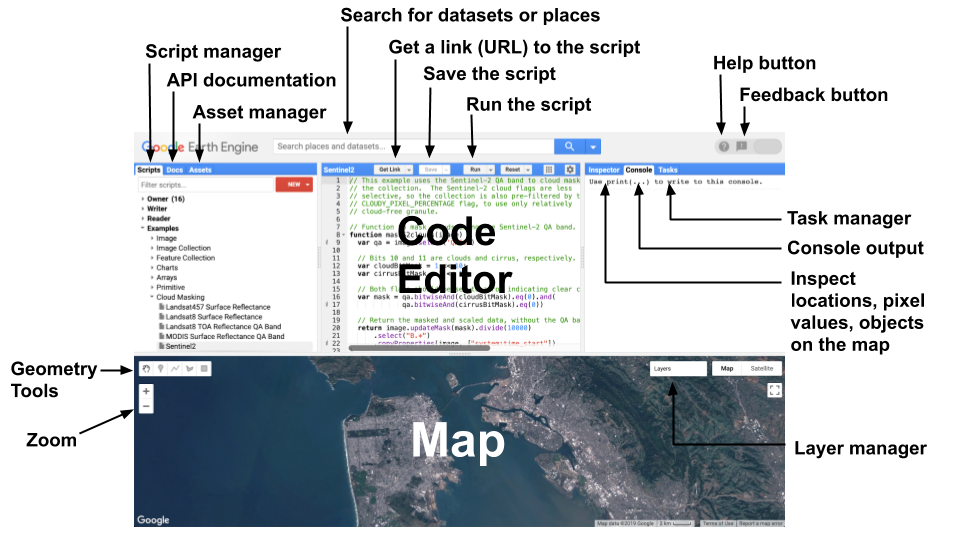

The **Python API** (`earthengine-api`, imported as `ee`) is the same API in a notebook or
script, and the reason most scientific work happens here: the result of an analysis lands
next to pandas, xarray, scikit-learn and your plotting library, and the whole workflow stays
reproducible in a single file. It ships no map of its own - `geemap` or `folium` provide
that. This is the client used throughout this chapter.

<style>
img[alt="image-5.png"] { width: 300px; }
</style>
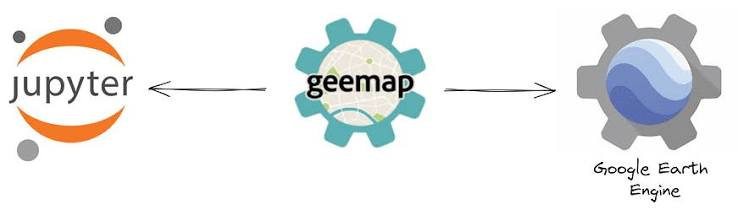


**R** and **Julia** are also covered, by the community packages `rgee` and `EarthEngine.jl`.
Both are wrappers around the Python API rather than independent implementations, so Python
must be installed underneath, and both are convenient if the rest of your analysis already
lives in those languages.

<style>
img[alt="image-4.png"] { width: 300px; }
</style>
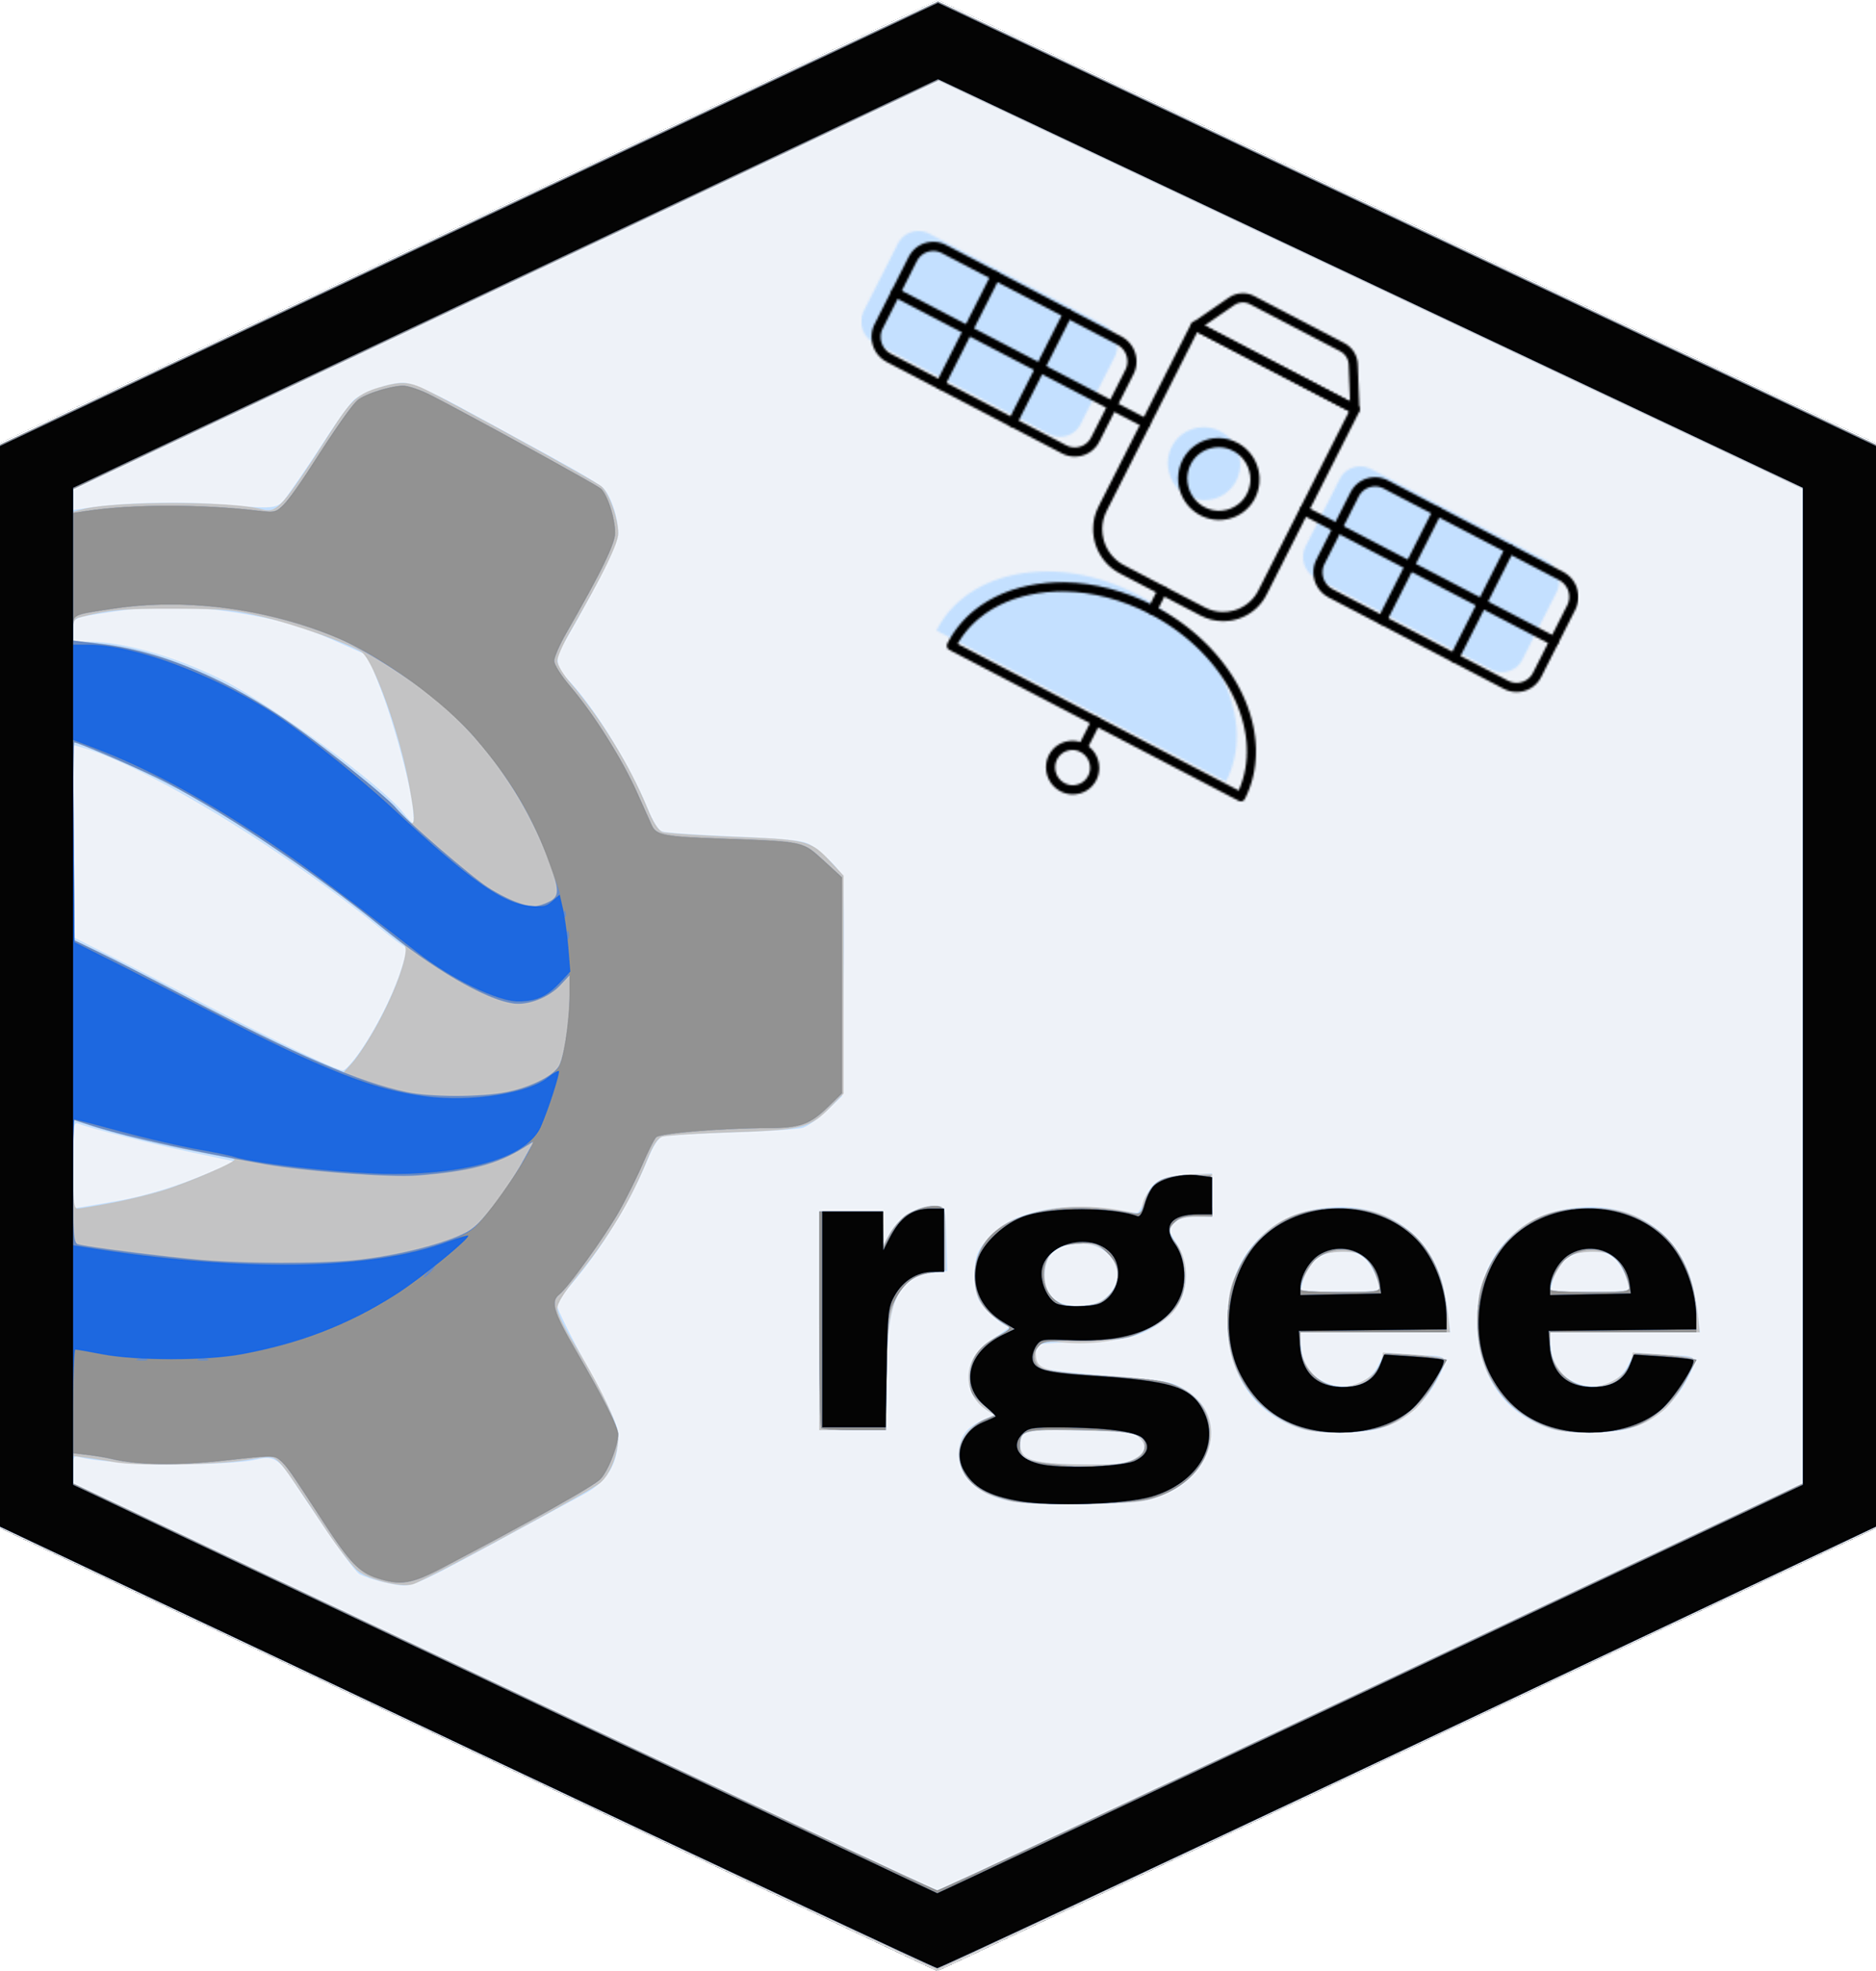

The important point is that these are four dialects of one API. The object types are the
same, the method names are the same, and only the syntax of the call differs -
`ee.Image('...')` in JavaScript and Python, `ee$Image('...')` in R. A script read in the
Code Editor translates to Python almost line by line, which is how you make use of the large
body of JavaScript examples while working in a notebook.

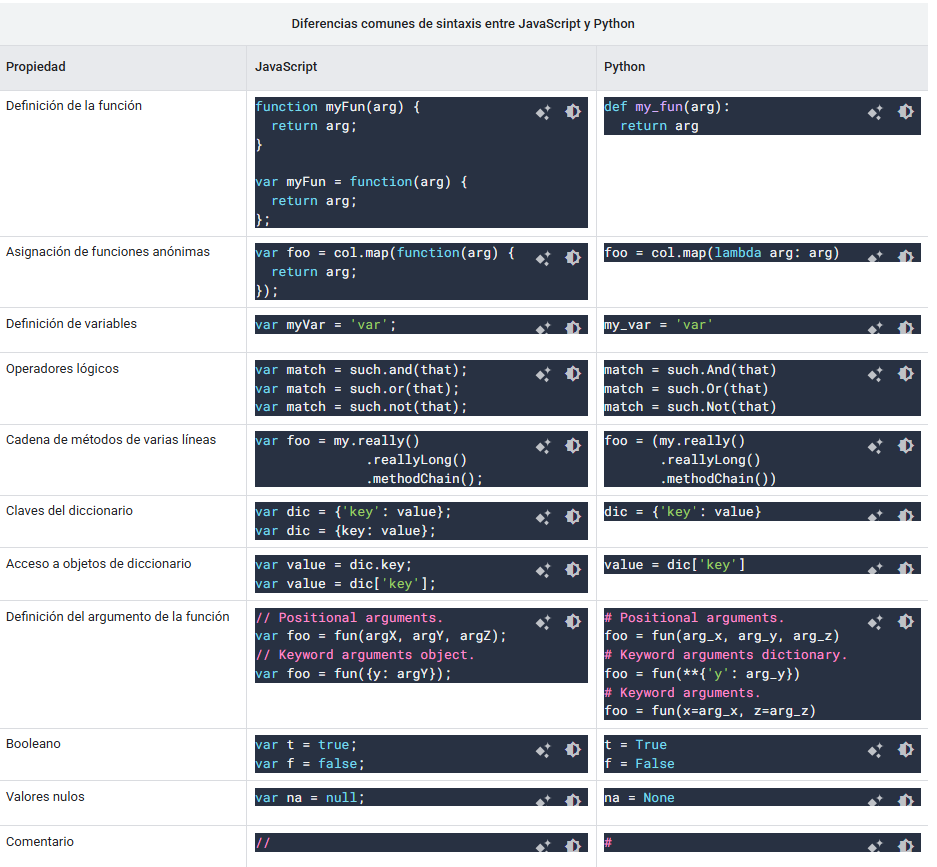

### The Earth Engine data catalogue

One of the main advantages of Earth Engine is its public data catalogue: several petabytes
of satellite imagery and geospatial datasets, already georeferenced, preprocessed and ready
to analyse. The data sits on Google's servers, so there is nothing to download or store
locally - you simply call a dataset by its ID (for example `NASA/NASADEM_HGT/001`) and the
computation runs in the cloud. Only the final result needs to be exported, if at all.

The catalogue covers, among others:

- **Optical imagery** - the full Landsat archive (from 1972 to the present), Sentinel-2 and MODIS.
- **Radar** - Sentinel-1 SAR, which sees through clouds and works day and night.
- **Elevation** - NASADEM, SRTM, Copernicus DEM and ALOS.
- **Climate and weather** - precipitation (CHIRPS, GPM), reanalyses (ERA5-Land) and
  TerraClimate.
- **Water** - the JRC Global Surface Water dataset, with the history of water occurrence
  since 1984.
- **Land cover** - ESA WorldCover, Dynamic World and MapBiomas.
- **Population and boundaries** - WorldPop, GHSL and administrative limits such as FAO GAUL.

Most datasets are updated regularly, and new scenes appear within a few days of acquisition.
Each dataset has its own page describing the bands, scaling factors, spatial and temporal
resolution, licence and a code example - it is worth reading before using any product.

Explore the catalogue here: <https://developers.google.com/earth-engine/datasets?hl=es-419>

<p align="center">
  <img src="https://developers.google.com/static/earth-engine/images/datasets/gifs/nasa_nex_07_2018.gif" width="32%">
  <img src="https://developers.google.com/static/earth-engine/images/datasets/gifs/modis_006_mod09ga.gif" width="32%">
  <img src="https://developers.google.com/static/earth-engine/images/datasets/gifs/dynamic_world_bissau.gif" width="32%">
</p>

This is the part that changes how you write code. When you write:

```python
dem = ee.Image("NASA/NASADEM_HGT/001")
```

no raster is loaded into your computer. `dem` is a **handle**: a description of an object
that lives on the server. The same applies to every operation you chain onto it - filters,
band arithmetic, reducers. The client library builds a description of the computation and
sends it to the server; the server executes it and returns only the result.


Consequences worth keeping in mind:

- **Evaluation is deferred.** Nothing is computed until a result is requested. The three
  requests are `getInfo()` (returns a value to Python), displaying a layer on a map (returns
  image tiles for the current view only), and `Export` (writes to Drive or an Asset).
- **Server objects and Python objects do not mix.** `ee.Number(3).add(4)` is computed on the
  server; `3 + 4` is computed locally. Mixing them - for instance using a Python `if` on a
  server-side value - does not work as expected, because the server value is not known
  locally until `getInfo()` is called.
- **`getInfo()` is the expensive operation.** It blocks until the server finishes and moves
  data across the network. Calling it inside a loop is the most common cause of slow
  notebooks.

### What it is used for, and what it is not

Earth Engine is designed for analyses over large areas or long time series, where the cost
of downloading and preprocessing the data would dominate the work: multi-decadal land cover
change, surface water dynamics over a basin, crop monitoring over a region.

<style>
img[alt="image-7.png"] { width: 500px; }
</style>
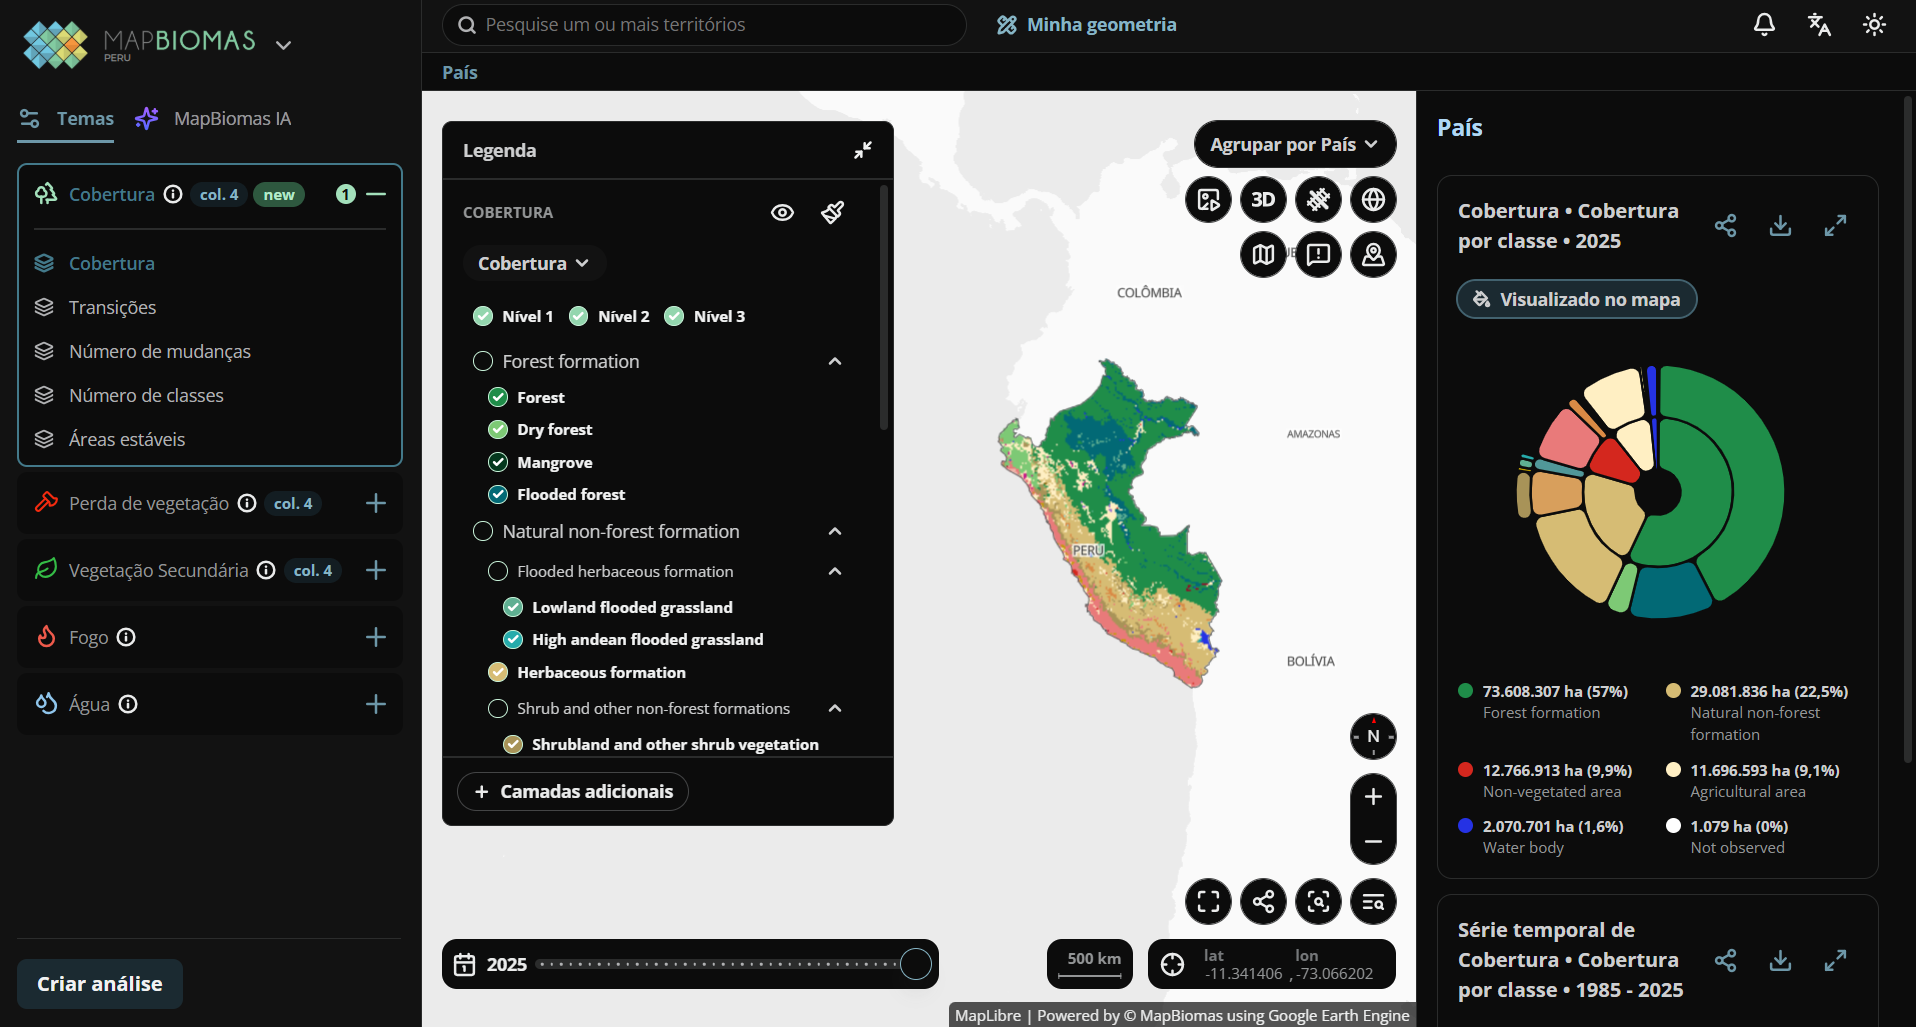

<style> img[alt="image-8.png"] { width: 500px; }
</style>
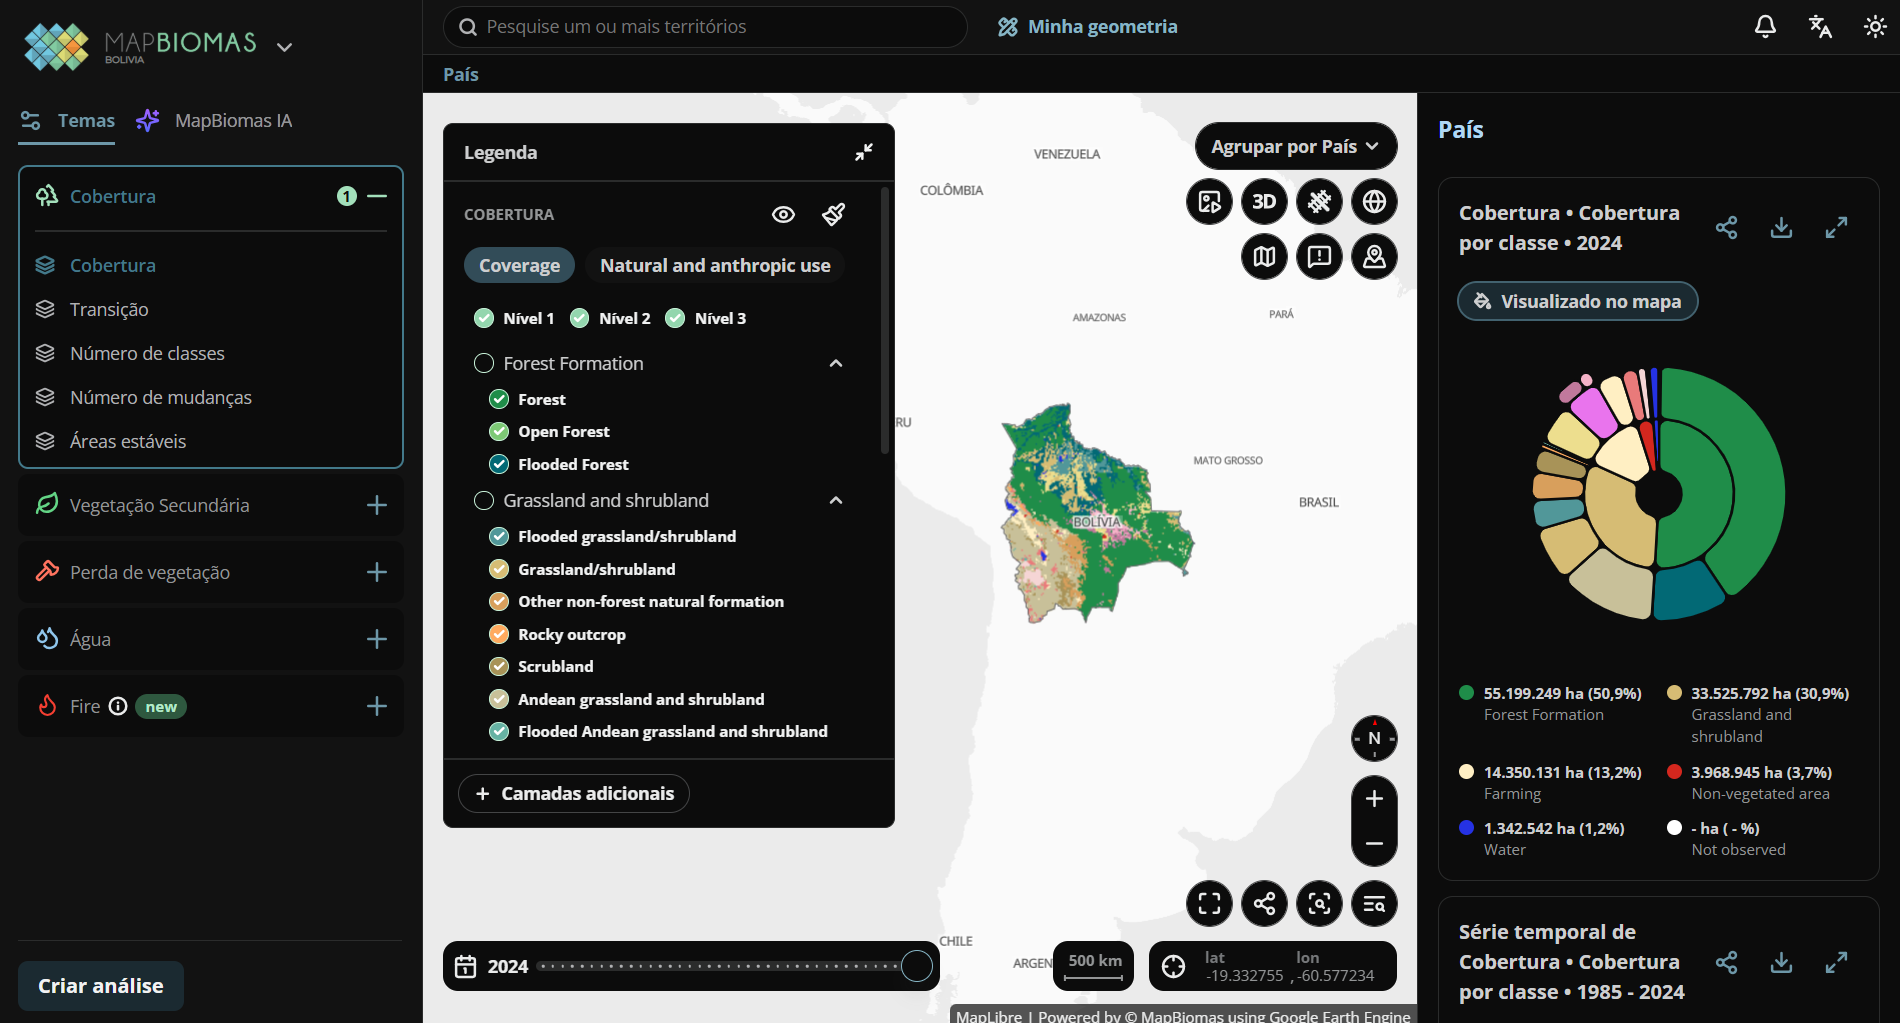

Examples: Mapbiomas Peru and Mapbiomas Bolivia 

It is not a replacement for a desktop GIS. Editing vectors, cartographic layout, and
workflows that need a specific local library are still done in QGIS or in Python outside
Earth Engine. Interactive computations also have time and memory limits: work that exceeds
them has to be moved to a batch `Export` task.

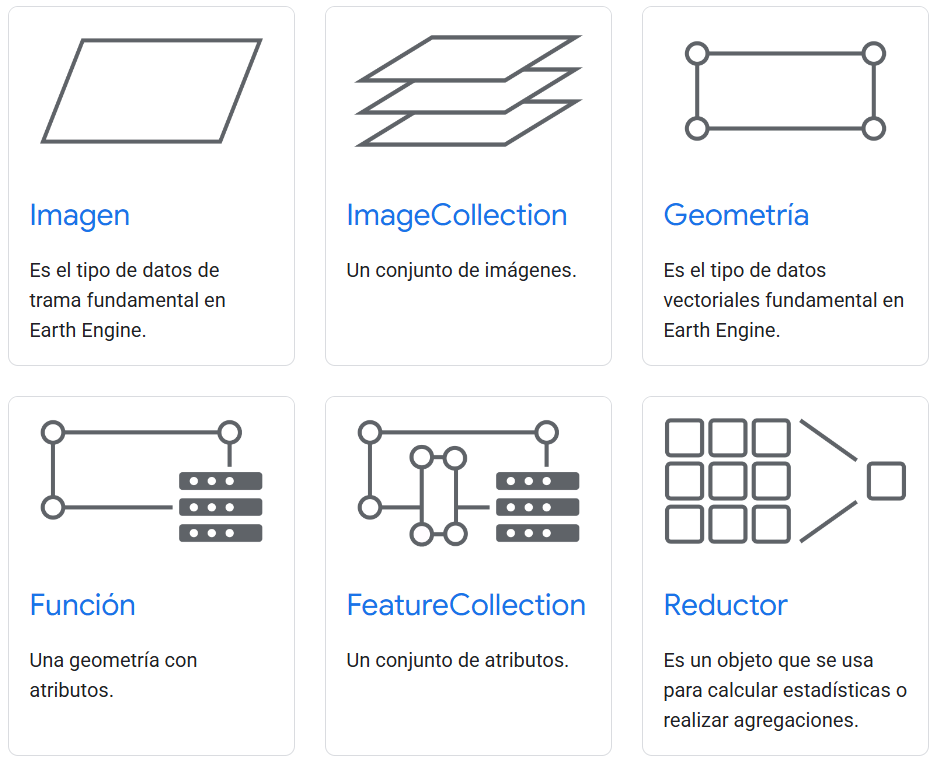
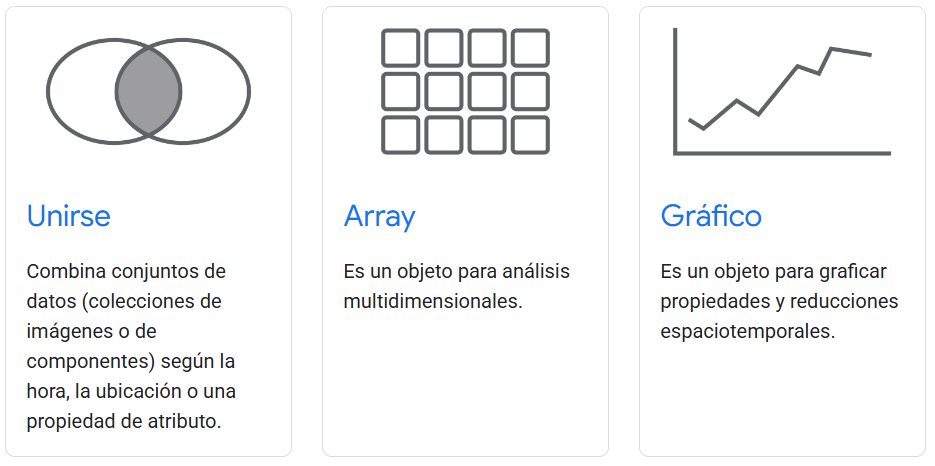

---

## 4.2 - Account, Cloud project and authentication

Earth Engine is free for research, education and non-commercial use, but access is tied to
a Google Cloud project. Do this once, before running anything else.

### Registration

1. Sign in with a Google account.
2. Go to **<https://code.earthengine.google.com/register>**.
3. Choose **Use with a Cloud Project**, then **Unpaid usage** and the purpose that applies
   (*Academia & Research*, for this course).
4. Create a new Cloud project or select an existing one. Note down the **project id** - a
   string such as `ee-yourname`. This is what the Python API needs.
5. Open the Code Editor at <https://code.earthengine.google.com/> to confirm the account
   works. Registration can take from a few minutes to a couple of days to be approved.

### The two functions

- **`ee.Authenticate()`** obtains the credentials. It opens a browser window (or prints a
  link) where you grant access, then stores a token on the machine. It only needs to be run
  again when the token expires or on a new machine.
- **`ee.Initialize(project="...")`** starts the session and binds it to the Cloud project.
  It has to run in every session, and it is where the project id is declared.

### Where this notebook runs

- **Google Colab** - nothing to install except `geemap`; authentication happens in the
  browser. The runtime is discarded when the session ends, so `ee.Authenticate()` runs again
  each time.
- **Locally (Jupyter, VS Code)** - install `earthengine-api` and `geemap` once; the token
  persists between sessions, so `ee.Initialize()` alone is usually enough.


In [ ]:
# ---------------------------------------------------------------------------
# Libraries (uncomment the pip line on a fresh runtime, e.g. Google Colab)
# ---------------------------------------------------------------------------
#%pip install -q earthengine-api geemap

import ee
import geemap

print("ee", ee.__version__, "| geemap", geemap.__version__)

In [ ]:
# ---------------------------------------------------------------------------
# Authenticate and initialise
# ---------------------------------------------------------------------------
# >>> REPLACE with your own Cloud project id <<<
EE_PROJECT = "ee-christhianscunha" #you need to create a project in Google Cloud and enable the Earth Engine API for it

ee.Authenticate()                     # stores the credentials on this machine
ee.Initialize(project=EE_PROJECT)     # starts the session

# A short server-side operation confirms that the connection works
print("Server test:", ee.Number(21).multiply(2).getInfo(), "(expected 42)")
print("Connected to project:", EE_PROJECT)

---

## 4.3 - Opening a single image: `ee.Image`

An `ee.Image` is one raster with one or more **bands**, plus metadata (`properties`). Here
we use **NASADEM**, a reprocessing of the SRTM elevation data at 30 m, distributed as a
single global image.

The methods below all return server-side objects; `getInfo()` is what brings a value back
into Python. Note that the image is global: asking for its metadata is cheap, but asking for
its pixels without restricting the area is not.


In [ ]:
# ---------------------------------------------------------------------------
# ee.Image - NASADEM (global digital elevation model, 30 m)
# ---------------------------------------------------------------------------
dem = ee.Image("NASA/NASADEM_HGT/001")

# Nothing has been computed yet - 'dem' is a description of a server-side object.
# getInfo() is what actually asks the server for a value.
print("Bands       :", dem.bandNames().getInfo())
print("Native scale:", dem.select("elevation").projection().nominalScale().getInfo(), "m")
print("Type        :", type(dem))

---

## 4.4 - Opening an image collection: `ee.ImageCollection`

An `ee.ImageCollection` is a stack of images sharing the same structure - typically every
scene a sensor has acquired. Here we use **Landsat 9** Collection 2 Level 2 (surface
reflectance), available since 2021.

A collection is not useful until it is filtered. Three filters are applied almost always:

| Filter | Purpose |
|---|---|
| `filterBounds(geometry)` | keeps the scenes that intersect an area |
| `filterDate(start, end)` | keeps the scenes of a period |
| `filter(ee.Filter.lt(...))` | keeps the scenes matching a metadata condition, such as cloud cover |

The bands are stored as integers and have to be rescaled with the Collection 2 Level 2 factors:

| Bands | Variable | Scaling |
|---|---|---|
| `SR_B1` - `SR_B7` | surface reflectance (0-1) | `0.0000275 * DN - 0.2` |
| `ST_B10` | surface temperature (Kelvin) | `0.00341802 * DN + 149.0` |

The function below applies both and is reused in the next examples.

In [ ]:
# ---------------------------------------------------------------------------
# ee.ImageCollection - Landsat 9 Collection 2 Level 2
# ---------------------------------------------------------------------------
l9 = ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")

# Band names of one image, to see what the collection contains.
# limit(1) avoids scanning the whole archive just to look at the structure.
print("Bands:", l9.limit(1).first().bandNames().getInfo())

# Shared parameters for the two examples below
START, END = "2025-09-01", "2026-09-01"
CLOUD_MAX = 30

def scale_l9(image):
    # Collection 2 Level 2 scaling factors
    optical = image.select("SR_B.").multiply(0.0000275).add(-0.2)      # reflectance (0-1)
    thermal = image.select("ST_B10").multiply(0.00341802).add(149.0)   # temperature (K)
    scaled = optical.addBands(thermal)
    return ee.Image(scaled.copyProperties(image, ["system:time_start", "CLOUD_COVER"]))

# Display parameters, reused by both maps
vis_rgb = {"bands": ["SR_B4", "SR_B3", "SR_B2"], "min": 0, "max": 0.3}   # natural colour
vis_nir = {"bands": ["SR_B5", "SR_B4", "SR_B3"], "min": 0, "max": 0.3}   # false colour

print("Period:", START, "to", END, "| cloud cover <", CLOUD_MAX, "%")

---

## 4.5 - Example 1: an area of interest defined by a point

The simplest way to locate an analysis is a pair of coordinates. `ee.Geometry.Point` takes
them in **[longitude, latitude]** order - the reverse of the [lat, lon] order used by most
map libraries, `geemap.Map(center=...)` included. Swapping them is a frequent error, and it
usually shows up as an empty collection.

A point has no area, so it cannot be used to clip an image, but it is enough for
`filterBounds()`: the filter keeps every scene whose footprint contains that point.


In [ ]:
# ---------------------------------------------------------------------------
# Example 1 - point: [longitude, latitude]
# ---------------------------------------------------------------------------
point = ee.Geometry.Point([-68.7849, -16.5523])   # Bolivian altiplano

l9_point = (l9.filterBounds(point)
              .filterDate(START, END)
              .filter(ee.Filter.lt("CLOUD_COVER", CLOUD_MAX))
              .map(scale_l9))

image_point = ee.Image(l9_point.sort("CLOUD_COVER").first())

print("Scenes containing the point:", l9_point.size().getInfo())
print("Least cloudy scene         :",
      ee.Date(image_point.get("system:time_start")).format("YYYY-MM-dd").getInfo(),
      "|", round(image_point.get("CLOUD_COVER").getInfo(), 1), "% cloud")

Map_point = geemap.Map(center=[-16.5523, -68.7849], zoom=10)   # note: [lat, lon] here
Map_point.addLayer(image_point, vis_rgb, "Landsat 9 - natural colour")
Map_point.addLayer(point, {"color": "red"}, "Point")
Map_point.add_layer_control()

Map_point

---

## 4.6 - Example 2: an area of interest drawn on the map

The drawing tools on the left toolbar produce Earth Engine geometries directly.
`Map.user_roi` returns the last geometry drawn, and `Map.user_rois` returns all of them as a
`FeatureCollection`. If nothing has been drawn, `user_roi` is `None`.

Draw a **rectangle or a polygon** on the map below, then run the next cell. Unlike a point,
a polygon has an area, so it can also be used to **clip** the image - which is what keeps the
display restricted to the area of interest.


In [ ]:
# ---------------------------------------------------------------------------
# Example 2 - draw a rectangle or polygon on this map, then run the next cell
# ---------------------------------------------------------------------------
Map_roi = geemap.Map(center=[-16.5523, -68.7849], zoom=10)
Map_roi.add_basemap("SATELLITE")

Map_roi

In [ ]:
# ---------------------------------------------------------------------------
# Filter and clip with the drawn geometry
# ---------------------------------------------------------------------------
roi = Map_roi.user_roi if Map_roi.user_roi is not None else point.buffer(15000).bounds()

l9_roi = (l9.filterBounds(roi)
            .filterDate(START, END)
            .filter(ee.Filter.lt("CLOUD_COVER", CLOUD_MAX))
            .map(scale_l9))

# median() combines the scenes into one image; clip() restricts it to the geometry
image_roi = l9_roi.median().clip(roi)

print("Scenes intersecting the area:", l9_roi.size().getInfo())
print("Area (km2)                  :",
      round(roi.area(maxError=1).divide(1e6).getInfo(), 1))

Map_roi.addLayer(image_roi, vis_rgb, "Landsat 9 - median, clipped")
Map_roi.addLayer(image_roi, vis_nir, "Landsat 9 - false colour", False)
Map_roi.addLayer(roi, {"color": "yellow"}, "Drawn area")
Map_roi.add_layer_control()
Map_roi.centerObject(roi, 11)

Map_roi

---

## 4.7 - Example 3: an area of interest from a `FeatureCollection` asset

A point and a drawn polygon are defined in the notebook. In practice the area of interest
usually already exists as a vector layer - a basin boundary, a set of plots, an
administrative division. Uploading it once as an **Earth Engine asset** makes it available
to every script, and to anyone the asset is shared with.

An asset is referenced by its full path:

```
projects/<project-id>/assets/<folder>/<name>
```

The asset used here, `projects/ee-christhianscunha/assets/transcend/TDP_map`, is a
`FeatureCollection`: a set of features, each with a geometry and a table of attributes.

Two operations are shown:

- **displaying the vector layer**, using `style()` to draw only the outlines, so the raster
  underneath stays visible;
- **clipping the NASADEM elevation image** with `clip(fc)`, which restricts the raster to the
  boundary of the collection.

`clip()` only affects what is displayed and computed inside the geometry; it does not
resample or modify the pixels.


In [ ]:
# ---------------------------------------------------------------------------
# Example 3 - FeatureCollection asset
# ---------------------------------------------------------------------------
tdp = ee.FeatureCollection("projects/ee-christhianscunha/assets/transcend/TDP_map")

print("Features  :", tdp.size().getInfo())
print("Attributes:", tdp.first().propertyNames().getInfo())

In [ ]:
# ---------------------------------------------------------------------------
# NASADEM elevation clipped by the FeatureCollection
# ---------------------------------------------------------------------------
elevation = dem.select("elevation").clip(tdp)

# Stretch the colour scale to the actual range of the area, instead of guessing it.
# scale=90 keeps the statistic fast; the data itself stays at 30 m.
stats = elevation.reduceRegion(reducer=ee.Reducer.minMax(), geometry=tdp.geometry(),
                               scale=90, maxPixels=1e9).getInfo()

vis_dem = {"min": stats["elevation_min"], "max": stats["elevation_max"],
           "palette": ["#f4f1e8", "#cfd8b4", "#9aae7d", "#5c7a54", "#26402f"]}

print("Elevation range: {} to {} m".format(stats["elevation_min"], stats["elevation_max"]))

Map_fc = geemap.Map()
Map_fc.addLayer(elevation, vis_dem, "NASADEM elevation (clipped)")
Map_fc.addLayer(tdp.style(color="#e34948", fillColor="00000000", width=2), {}, "TDP_map")
Map_fc.add_layer_control()
Map_fc.centerObject(tdp)

Map_fc

### Comparing the three approaches

| | Defined by | Filters a collection | Clips a raster | Reusable |
|---|---|---|---|---|
| **Point** | coordinates in the code | yes | no (no area) | yes, if the coordinates are recorded |
| **Drawn geometry** | interaction with the map | yes | yes | no - it is lost when the notebook is restarted |
| **Asset** | a vector file uploaded once | yes | yes | yes, across scripts and users |

A drawn geometry is convenient for exploring and for teaching, but it makes an analysis
impossible to reproduce: nobody else can redraw the same polygon. Work that has to be
repeated or shared should use an asset, or coordinates written explicitly in the code.


---

## 4.8 - Downloading the results

To open the results in QGIS, the images have to be exported as GeoTIFF files. Two ways:

- **Direct download** with `geemap.ee_export_image()` - the file is saved on your computer. Only for small files.
- **Export task** with `ee.batch.Export.image.toDrive()` - Earth Engine processes it in the background and saves the file in your Google Drive.

### 4.8.1 - NASADEM: direct download to the computer

We download `elevation`, the NASADEM clipped by `TDP_map` (section 4.7).

In [ ]:
# ---------------------------------------------------------------------------
# NASADEM clipped by TDP_map -> GeoTIFF on this computer
# ---------------------------------------------------------------------------
geemap.ee_export_image(
    elevation,                        # from section 4.7
    filename="nasadem_tdp.tif",
    scale=250,                        # pixel size (m); the basin is too large for a direct download at 30 m
    region=tdp.geometry(),
)

# On Google Colab: send the file to your browser's Downloads folder
try:
    from google.colab import files
    files.download("nasadem_tdp.tif")
except ImportError:
    pass

### 4.8.2 - Landsat 9: export task to Google Drive

We export `image_roi`, the Landsat 9 median composite of section 4.6, with the optical
bands and the thermal band. The file appears in the `TRANSCEND_GEE` folder of your Drive
after a few minutes; the progress can be followed at <https://code.earthengine.google.com/tasks>.

In [ ]:
# ---------------------------------------------------------------------------
# Landsat 9 composite (optical + thermal) -> Google Drive
# ---------------------------------------------------------------------------
bands = ["SR_B2", "SR_B3", "SR_B4", "SR_B5", "SR_B6", "SR_B7", "ST_B10"]

task = ee.batch.Export.image.toDrive(
    image=image_roi.select(bands).toFloat(),   # from section 4.6
    description="L9_median_roi",
    folder="TRANSCEND_GEE",
    region=roi,
    scale=30,
    crs="EPSG:32719",                          # UTM 19S (Bolivian altiplano)
    maxPixels=1e10,
)
task.start()

print(task.status()["state"])   # run task.status() again later to check the progress

---

## 4.9 - Ejercicio / Exercise

**Consigna / Task**

1. Choose a different area, and define it in the three ways: a point with its coordinates,
   a geometry drawn on the map, and - if you have one - a vector asset of your own.
2. Load a different collection from the catalogue
   (<https://developers.google.com/earth-engine/datasets>) - for example Sentinel-2
   (`COPERNICUS/S2_SR_HARMONIZED`) or Sentinel-1 (`COPERNICUS/S1_GRD`) - and apply the
   same three filters.
3. Export the result for your area: download a small clip directly to your computer and
   send the full image to Google Drive as a task, then open both files in QGIS.
4. Report, for your area: how many scenes the filter returned, the date of the least cloudy
   one, and a screenshot of the visualisation.
5. Answer:
   - What happens to the number of scenes if you raise the cloud threshold from 30% to 60%?
   - What happens if you invert the order of the coordinates in `ee.Geometry.Point`?
     Explain the result.
   - Why does `filterBounds()` accept a point, while `clip()` does not produce a usable
     result with one?

**Entregable / Deliverable:** the notebook with the three examples running over your own
area, plus short written answers to the questions above.


---

## Referencias / References

**Official documentation**

- Earth Engine registration: <https://code.earthengine.google.com/register>
- Guides (concepts, client vs server, best practices): <https://developers.google.com/earth-engine/guides>
- **Tutorials**: <https://developers.google.com/earth-engine/tutorials>
- Data catalogue: <https://developers.google.com/earth-engine/datasets>
- Python API installation: <https://developers.google.com/earth-engine/guides/python_install>
- Managing assets: <https://developers.google.com/earth-engine/guides/asset_manager>

**Book (open access)**

- Cardille, J.A., Crowley, M.A., Saah, D., Clinton, N.E. (eds.) (2023).
  *Cloud-Based Remote Sensing with Google Earth Engine: Fundamentals and Applications*.
  Springer. Free to download, with all the scripts available.
  - Companion site: <https://www.eefabook.org/>
  - Publisher (open access): <https://link.springer.com/book/10.1007/978-3-031-26588-4>

**Courses and video material**

- **AmbGEO** - training in geotechnologies and Earth Engine, in Portuguese, with free courses
  and recorded material:
  - <https://ambgeo.com/>
  - YouTube: <https://www.youtube.com/@ambgeo>

**Python tools**

- geemap documentation and tutorials: <https://geemap.org>
- Wu, Q. (2020). geemap: A Python package for interactive mapping with Google Earth Engine.
  *Journal of Open Source Software*, 5(51), 2305.

**Reference article**

- Gorelick, N., Hancher, M., Dixon, M., Ilyushchenko, S., Thau, D., Moore, R. (2017).
  Google Earth Engine: Planetary-scale geospatial analysis for everyone.
  *Remote Sensing of Environment*, 202, 18-27.

**Data used in this notebook**

- NASADEM: <https://developers.google.com/earth-engine/datasets/catalog/NASA_NASADEM_HGT_001>
- Landsat 9 C2 L2: <https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LC09_C02_T1_L2>
